In [1]:
import torch

In [2]:
x = [[1,2],[3,4],[5,6],[7,8]]
y = [[3],[7],[11],[15]]

In [3]:
X = torch.tensor(x).float()
Y = torch.tensor(y).float()

In [4]:
device = 'mps' if torch.backends.mps.is_available() else 'cpu'

In [5]:
X = X.to(device)
Y = Y.to(device)

In [6]:
import torch.nn as nn 

In [7]:
class MyNeuralNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_to_hidden_layer = nn.Linear(2,8)
        self.hidden_layer_activation = nn.ReLU()
        self.hidden_to_output_layer = nn.Linear(8,1)
        
    def forward(self, x):
        x = self.input_to_hidden_layer(x)
        x = self.hidden_layer_activation(x)
        x = self.hidden_to_output_layer(x)
        return x
    

In [8]:
my_net = MyNeuralNet().to(device)

In [9]:
my_net.input_to_hidden_layer.weight

Parameter containing:
tensor([[-0.2246, -0.3739],
        [ 0.0275, -0.4115],
        [-0.5951, -0.1276],
        [-0.3994, -0.6760],
        [ 0.0456, -0.6072],
        [ 0.0628, -0.5710],
        [-0.2804,  0.6921],
        [-0.2447, -0.5896]], device='mps:0', requires_grad=True)

In [10]:
for par in my_net.parameters():
    print(par)

Parameter containing:
tensor([[-0.2246, -0.3739],
        [ 0.0275, -0.4115],
        [-0.5951, -0.1276],
        [-0.3994, -0.6760],
        [ 0.0456, -0.6072],
        [ 0.0628, -0.5710],
        [-0.2804,  0.6921],
        [-0.2447, -0.5896]], device='mps:0', requires_grad=True)
Parameter containing:
tensor([-0.0782, -0.2724, -0.4001,  0.3461,  0.6380,  0.6584, -0.3698,  0.6561],
       device='mps:0', requires_grad=True)
Parameter containing:
tensor([[-0.3280, -0.3345,  0.2395, -0.2711, -0.2847,  0.2872, -0.1998,  0.2601]],
       device='mps:0', requires_grad=True)
Parameter containing:
tensor([0.2851], device='mps:0', requires_grad=True)


In [11]:
loss_func = nn.MSELoss()

In [12]:
_Y = my_net(X)
loss_value = loss_func(_Y,Y)
print(loss_value)

tensor(104.6373, device='mps:0', grad_fn=<MseLossBackward0>)


In [13]:
from torch.optim import SGD
opt = SGD(my_net.parameters(), lr = 0.001)

In [14]:
loss_history = []
for _ in range(50):
    opt.zero_grad()
    loss_value = loss_func(my_net(X),Y)
    loss_value.backward()
    opt.step()
    loss_history.append(loss_value.item())

Text(0, 0.5, 'loss value')

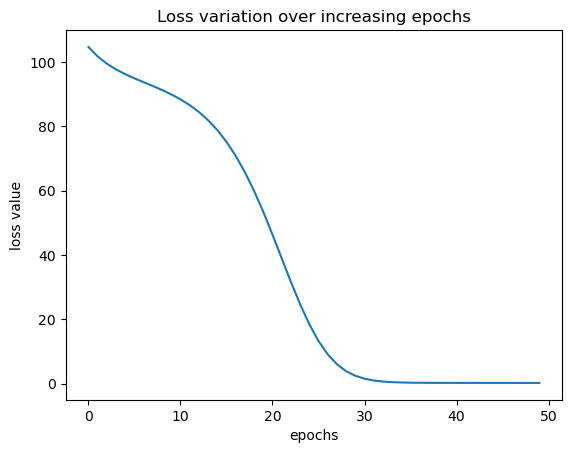

In [15]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.plot(loss_history)
plt.title('Loss variation over increasing epochs')
plt.xlabel('epochs')
plt.ylabel('loss value')

## steps for a NN 

1. inherint from torch.nn.Module
2. init using the super class and define the layers inside the constructor 
3. make the forward funciton which is basically how the data will flow inside the NN
4. outside the class make an optimizer 
5. pass teh NN parameters inside the optimizer and the learning rate 
6. now for every epoch do the following:

    a. flash the grad using opt.zero_grad().

    b. pass the input.

    c. calculate the loss.

    d. call backward on the loss.

    e. perform a step.
    
    f. make note of the loss.